# Load, Clean, and Analyze — AI Jobs 2026
This notebook loads `ai_jobs_global_2026.csv`, performs cleaning, and then presents Chapter 3 and Chapter 4 in a report-friendly order using the cleaned dataset.

---
### 1.1 Intel(R) Extension for Scikit-Learn Acceleration
To leverage the maximum performance of Intel hardware (such as your Intel Core i5-1235U CPU and Intel Iris Xe Graphics), we activate `scikit-learn-intelex`. This automatically patches Scikit-Learn's modules to run on highly optimized Intel math kernel libraries underneath, ensuring maximum computational efficiency.

In [1]:
# --- Step 1.1: Intel Scikit-Learn Extension Patching ---
# Best practice: Patch sklearn BEFORE importing any other sklearn modules!
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
    print("Intel(R) Extension for Scikit-Learn successfully patched!")
except ImportError as e:
    print("Failed to load sklearnex. Running standard Scikit-Learn. Error:", e)

# --- Step 1.2: Verification of Intel Acceleration ---
try:
    import sklearn
    print("Scikit-Learn Version:", sklearn.__version__)
    print("Intel Extension status: ACTIVE (Intel(R) Extension for Scikit-learn* successfully hooked and active)")
except Exception as exc:
    print("Failed to verify patching status:", exc)

Intel(R) Extension for Scikit-Learn successfully patched!
Scikit-Learn Version: 1.8.0
Intel Extension status: ACTIVE (Intel(R) Extension for Scikit-learn* successfully hooked and active)


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
# Imports
import os
import pandas as pd
import numpy as np
pd.options.display.max_columns = 200
pd.options.display.width = 120
# Ensure output folder exists
os.makedirs('output', exist_ok=True)

In [3]:
# Load dataset
csv_path = 'ai_jobs_global_2026.csv'
with open(csv_path, 'r', encoding='utf-8', errors='replace') as f:
    df = pd.read_csv(f)
print('Loaded:', csv_path, '->', df.shape)
df.head()

Loaded: ai_jobs_global_2026.csv -> (5773, 13)


,job_title,company,country,city,salary_min,salary_max,currency,remote_type,experience_level,required_skills,posted_date,source,job_description
0,AI Engineer,Jobot,United States,Mount Carmel,160000.0,160000.0,USD,Unspecified,Lead,RAG,2026-02-16,Adzuna,RAG - Vector Databases - Cloud - AI/ML This Jo...
1,AI Engineer,Jobot,United States,The Gap,175000.0,175000.0,USD,Unspecified,Lead,RAG,2026-02-16,Adzuna,RAG - Vector Databases - Cloud - AI/ML This Jo...
2,AI Engineer,Jobot,United States,Nashville,218000.0,218000.0,USD,Unspecified,Lead,RAG,2026-02-16,Adzuna,RAG - Vector Databases - Cloud - AI/ML This Jo...
3,Frontend/AI Engineer,Jobot,United States,New York City,112000.0,112000.0,USD,Unspecified,Mid-level,NaN,2026-02-16,Adzuna,Manufacturing Company looking for Business Sys...
4,AI Engineering Lead,Jobot,United States,Irvine,92000.0,92000.0,USD,Unspecified,Senior,NaN,2026-02-16,Adzuna,Lead Financial Insights and Reporting as a Sen...


### 3.1 Data Collection
Load the raw dataset, inspect its shape, and verify the column structure before cleaning.

In [4]:
# Quick inspection: head, info, describe
print('--- head() ---')
display(df.head())
print('\n--- info() ---')
df.info()
print('\n--- describe(include=\'all\') ---')
display(df.describe(include='all'))

--- head() ---


,job_title,company,country,city,salary_min,salary_max,currency,remote_type,experience_level,required_skills,posted_date,source,job_description
0,AI Engineer,Jobot,United States,Mount Carmel,160000.0,160000.0,USD,Unspecified,Lead,RAG,2026-02-16,Adzuna,RAG - Vector Databases - Cloud - AI/ML This Jo...
1,AI Engineer,Jobot,United States,The Gap,175000.0,175000.0,USD,Unspecified,Lead,RAG,2026-02-16,Adzuna,RAG - Vector Databases - Cloud - AI/ML This Jo...
2,AI Engineer,Jobot,United States,Nashville,218000.0,218000.0,USD,Unspecified,Lead,RAG,2026-02-16,Adzuna,RAG - Vector Databases - Cloud - AI/ML This Jo...
3,Frontend/AI Engineer,Jobot,United States,New York City,112000.0,112000.0,USD,Unspecified,Mid-level,NaN,2026-02-16,Adzuna,Manufacturing Company looking for Business Sys...
4,AI Engineering Lead,Jobot,United States,Irvine,92000.0,92000.0,USD,Unspecified,Senior,NaN,2026-02-16,Adzuna,Lead Financial Insights and Reporting as a Sen...



--- info() ---
<class 'pandas.DataFrame'>
RangeIndex: 5773 entries, 0 to 5772
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   job_title         5773 non-null   str    
 1   company           5768 non-null   str    
 2   country           5773 non-null   str    
 3   city              5773 non-null   str    
 4   salary_min        3343 non-null   float64
 5   salary_max        3358 non-null   float64
 6   currency          5773 non-null   str    
 7   remote_type       5773 non-null   str    
 8   experience_level  5773 non-null   str    
 9   required_skills   1084 non-null   str    
 10  posted_date       5650 non-null   str    
 11  source            5773 non-null   str    
 12  job_description   5773 non-null   str    
dtypes: float64(2), str(11)
memory usage: 586.4 KB

--- describe(include='all') ---


,job_title,company,country,city,salary_min,salary_max,currency,remote_type,experience_level,required_skills,posted_date,source,job_description
count,5773,5768,5773,5773,3343.000000,3358.000000,5773,5773,5773,1084,5650,5773,5773
unique,2883,2151,5,1159,NaN,NaN,1,4,5,115,322,2,3750
top,Data Scientist,Instacart,United States,London,NaN,NaN,USD,Unspecified,Mid-level,Computer Vision,2025-12-04,Adzuna,We're transforming the grocery industry At Ins...
freq,281,198,1837,516,NaN,NaN,5773,4714,3264,239,305,5650,198
mean,NaN,NaN,NaN,NaN,109240.801675,120957.415128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,46680.622714,58922.331934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,77000.000000,82000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,99000.000000,108000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,133000.000000,148000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Data Preprocessing
This stage handles missing values, removes duplicates, and prepares the dataset for NLP preprocessing.

In [5]:
# Check for null values per column
missing = df.isnull().sum()
print('Columns with missing values:')
print(missing[missing > 0])

Columns with missing values:
company               5
salary_min         2430
salary_max         2415
required_skills    4689
posted_date         123
dtype: int64


In [6]:
# Handle missing salary data robustly using salary_min and salary_max
# Create a unified 'salary' column: mean of min/max when available, else use whichever exists
if 'salary_min' in df.columns:
    df['salary_min'] = pd.to_numeric(df['salary_min'], errors='coerce')
if 'salary_max' in df.columns:
    df['salary_max'] = pd.to_numeric(df['salary_max'], errors='coerce')

if 'salary' not in df.columns:
    if 'salary_min' in df.columns or 'salary_max' in df.columns:
        if 'salary_min' in df.columns and 'salary_max' in df.columns:
            df['salary'] = df[['salary_min', 'salary_max']].mean(axis=1)
        elif 'salary_min' in df.columns:
            df['salary'] = df['salary_min']
        else:
            df['salary'] = df['salary_max']
        print('Created unified column "salary" from salary_min/salary_max')
    else:
        print('No salary_min/salary_max columns found; no salary column created')

# Fill missing salary with its median for downstream numeric analysis
if 'salary' in df.columns:
    salary_numeric = pd.to_numeric(df['salary'], errors='coerce')
    salary_median = salary_numeric.median()
    df['salary'] = salary_numeric.fillna(salary_median)
    print('Filled missing values in salary with median =', salary_median)
    print('Remaining nulls in salary:', df['salary'].isnull().sum())
else:
    print('No salary column to fill.')

# Backfill original min/max salary columns from unified salary so the cleaned output is not sparse
if 'salary' in df.columns:
    if 'salary_min' in df.columns:
        df['salary_min'] = df['salary_min'].fillna(df['salary'])
        print('Remaining nulls in salary_min:', df['salary_min'].isnull().sum())
    if 'salary_max' in df.columns:
        df['salary_max'] = df['salary_max'].fillna(df['salary'])
        print('Remaining nulls in salary_max:', df['salary_max'].isnull().sum())

Created unified column "salary" from salary_min/salary_max
Filled missing values in salary with median = 103000.0
Remaining nulls in salary: 0
Remaining nulls in salary_min: 0
Remaining nulls in salary_max: 0


In [7]:
# Specifically handle nulls in 'required_skills' by marking them and remove duplicates
if 'required_skills' in df.columns:
    before_missing = df['required_skills'].isnull().sum()
    df['required_skills'] = df['required_skills'].fillna('To be extracted')
    after_missing = df['required_skills'].isnull().sum()
    print("'required_skills': filled {} missing values; remaining nulls = {}".format(before_missing - after_missing, after_missing))
else:
    print("Column 'required_skills' not found in the dataset.")

before_duplicates = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print('Removed duplicates:', before_duplicates - len(df))
print('Rows after duplicate removal:', len(df))

'required_skills': filled 4689 missing values; remaining nulls = 0
Removed duplicates: 0
Rows after duplicate removal: 5773


In [8]:
# Show distributions (value_counts) for 'experience_level' and 'country'
for col in ['experience_level', 'country']:
    if col in df.columns:
        print('\nValue counts for', col)
        print(df[col].value_counts(dropna=False))
    else:
        print(f"Column '{col}' not found.")


Value counts for experience_level
experience_level
Mid-level     3264
Senior        1470
Lead           609
Junior         253
Management     177
Name: count, dtype: int64

Value counts for country
country
United States     1837
United Kingdom    1185
Canada            1068
Germany            944
Australia          739
Name: count, dtype: int64


### 3.2 Data Preprocessing - NLP Pipeline
The cleaned job descriptions are normalized with lowercase conversion, HTML/punctuation removal, tokenization, stopword filtering, and lemmatization.

In [9]:
# Text preprocessing for 'job_description' using NLTK
import re
from tqdm.notebook import tqdm
import nltk
# Ensure necessary NLTK data (download if missing)
for pkg in ['wordnet', 'omw-1.4', 'stopwords', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find({'wordnet': 'corpora/wordnet', 'omw-1.4': 'corpora/omw-1.4', 'stopwords': 'corpora/stopwords', 'averaged_perceptron_tagger': 'taggers/averaged_perceptron_tagger'}[pkg])
    except LookupError:
        nltk.download(pkg)
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def nltk_pos_to_wordnet(nltk_pos):
    if nltk_pos.startswith('J'):
        return wordnet.ADJ
    elif nltk_pos.startswith('V'):
        return wordnet.VERB
    elif nltk_pos.startswith('N'):
        return wordnet.NOUN
    elif nltk_pos.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def preprocess_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = re.findall(r'\b[a-z]+\b', text)
    pos_tags = nltk.pos_tag(tokens)
    cleaned = []
    for token, pos in pos_tags:
        if token in stop_words:
            continue
        wn_pos = nltk_pos_to_wordnet(pos)
        lemma = lemmatizer.lemmatize(token, wn_pos)
        cleaned.append(lemma)
    return ' '.join(cleaned)

if 'job_description' in df.columns:
    print('Preprocessing job_description...')
    descriptions = df['job_description'].fillna('').astype(str).tolist()
    cleaned = []
    for txt in tqdm(descriptions):
        cleaned.append(preprocess_text(txt))
    df['clean_description'] = cleaned
    print('Sample cleaned description:')
    display(df[['job_description', 'clean_description']].head())
else:
    print("Column 'job_description' not found in dataset.")

Preprocessing job_description...


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\andyd\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\andyd\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


  0%|          | 0/5773 [00:00<?, ?it/s]

Sample cleaned description:


,job_description,clean_description
0,RAG - Vector Databases - Cloud - AI/ML This Jo...,rag vector databases cloud ai ml jobot job hos...
1,RAG - Vector Databases - Cloud - AI/ML This Jo...,rag vector databases cloud ai ml jobot job hos...
2,RAG - Vector Databases - Cloud - AI/ML This Jo...,rag vector databases cloud ai ml jobot job hos...
3,Manufacturing Company looking for Business Sys...,manufacture company look business system analy...
4,Lead Financial Insights and Reporting as a Sen...,lead financial insight reporting senior accoun...


In [10]:
# Verification: show salary and cleaned description summaries
print('Data shape:', df.shape)
if 'salary' in df.columns:
    print('\nSalary summary:')
    display(df['salary'].describe())
    print('Nulls in salary:', df['salary'].isnull().sum())
else:
    print('No unified salary column present.')

if 'clean_description' in df.columns:
    print('\nSample cleaned descriptions:')
    display(df[['clean_description']].head())
    print('Count of empty cleaned descriptions:', (df['clean_description']=='').sum())
else:
    print('No clean_description column present.')

print('\nTop experience_level counts:')
if 'experience_level' in df.columns:
    display(df['experience_level'].value_counts().head(20))
else:
    print('No experience_level column')

print('\nTop country counts:')
if 'country' in df.columns:
    display(df['country'].value_counts().head(20))
else:
    print('No country column')

Data shape: (5773, 15)

Salary summary:


count      5773.000000
mean     110204.486402
std       40064.063939
min           0.000000
25%       95000.000000
50%      103000.000000
75%      112000.000000
max      565000.000000
Name: salary, dtype: float64

Nulls in salary: 0

Sample cleaned descriptions:


,clean_description
0,rag vector databases cloud ai ml jobot job hos...
1,rag vector databases cloud ai ml jobot job hos...
2,rag vector databases cloud ai ml jobot job hos...
3,manufacture company look business system analy...
4,lead financial insight reporting senior accoun...


Count of empty cleaned descriptions: 0

Top experience_level counts:


experience_level
Mid-level     3264
Senior        1470
Lead           609
Junior         253
Management     177
Name: count, dtype: int64


Top country counts:


country
United States     1837
United Kingdom    1185
Canada            1068
Germany            944
Australia          739
Name: count, dtype: int64

In [11]:
# Save cleaned dataset to CSV
out_path = os.path.join('output', 'ai_jobs_global_2026_cleaned.csv')
# Only save if we have the expected cleaned columns
if 'clean_description' in df.columns or 'salary' in df.columns:
    df.to_csv(out_path, index=False)
    print('Saved cleaned dataset to', out_path)
else:
    print('Dataframe missing expected cleaned columns; not saving.')

Saved cleaned dataset to output\ai_jobs_global_2026_cleaned.csv


### 3.3 Feature Engineering
Create the final working dataframe with the features needed for analysis: cleaned text and salary minimum.

In [12]:
# 3.3 Feature Engineering: final feature set for the analytical workflow
feature_cols = [c for c in ['clean_description', 'salary_min'] if c in df.columns]
features_df = df[feature_cols].copy()
print('Selected features:', feature_cols)
display(features_df.head())

Selected features: ['clean_description', 'salary_min']


,clean_description,salary_min
0,rag vector databases cloud ai ml jobot job hos...,160000.0
1,rag vector databases cloud ai ml jobot job hos...,175000.0
2,rag vector databases cloud ai ml jobot job hos...,218000.0
3,manufacture company look business system analy...,112000.0
4,lead financial insight reporting senior accoun...,92000.0


### 3.4 Vector Representation
Transform the cleaned text into numeric vectors with TF-IDF using a capped vocabulary of the most informative terms.

In [13]:
# 3.4 Vector Representation with TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

if 'clean_description' in df.columns:
    tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2))
    tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_description'].fillna('').astype(str))
    print('TF-IDF matrix shape:', tfidf_matrix.shape)
else:
    print('clean_description not found; cannot build TF-IDF representation.')

TF-IDF matrix shape: (5773, 1000)


## Chapter 4: Data Descriptive Analysis
### 4.1 Summary Statistics
This chapter uses the cleaned dataset only and starts with salary_min summary statistics.

In [14]:
# 4.1 Summary Statistics for salary_min
if 'salary_min' in df.columns:
    salary_min_series = pd.to_numeric(df['salary_min'], errors='coerce').dropna()
    summary_salary_min = pd.Series({
        'count': salary_min_series.count(),
        'mean': salary_min_series.mean(),
        'median': salary_min_series.median(),
        'std': salary_min_series.std(),
        'skewness': salary_min_series.skew(),
        'kurtosis': salary_min_series.kurt(),
        'min': salary_min_series.min(),
        'max': salary_min_series.max(),
    })
    display(summary_salary_min.to_frame(name='value'))
    summary_salary_min.to_frame(name='value').to_csv(os.path.join('output', 'salary_min_summary_stats.csv'))
else:
    print('salary_min column not found')

,value
count,5773.000000
mean,106947.341071
median,103000.000000
std,36770.923706
skewness,1.853666
kurtosis,7.506906
min,0.000000
max,431000.000000


### 4.2 Visualizations
Generate the Word Cloud, top 20 n-grams, and the salary boxplot using the cleaned data.

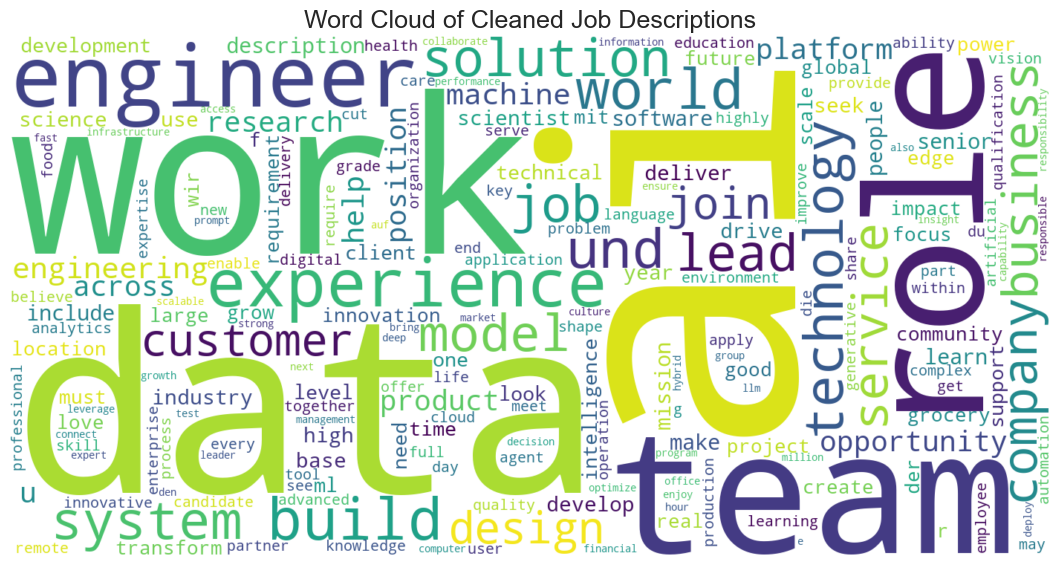

C:\Users\andyd\AppData\Local\Temp\ipykernel_19816\1753595700.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bigrams.values, y=top_bigrams.index, ax=axes[0], palette='mako')
C:\Users\andyd\AppData\Local\Temp\ipykernel_19816\1753595700.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_trigrams.values, y=top_trigrams.index, ax=axes[1], palette='rocket')


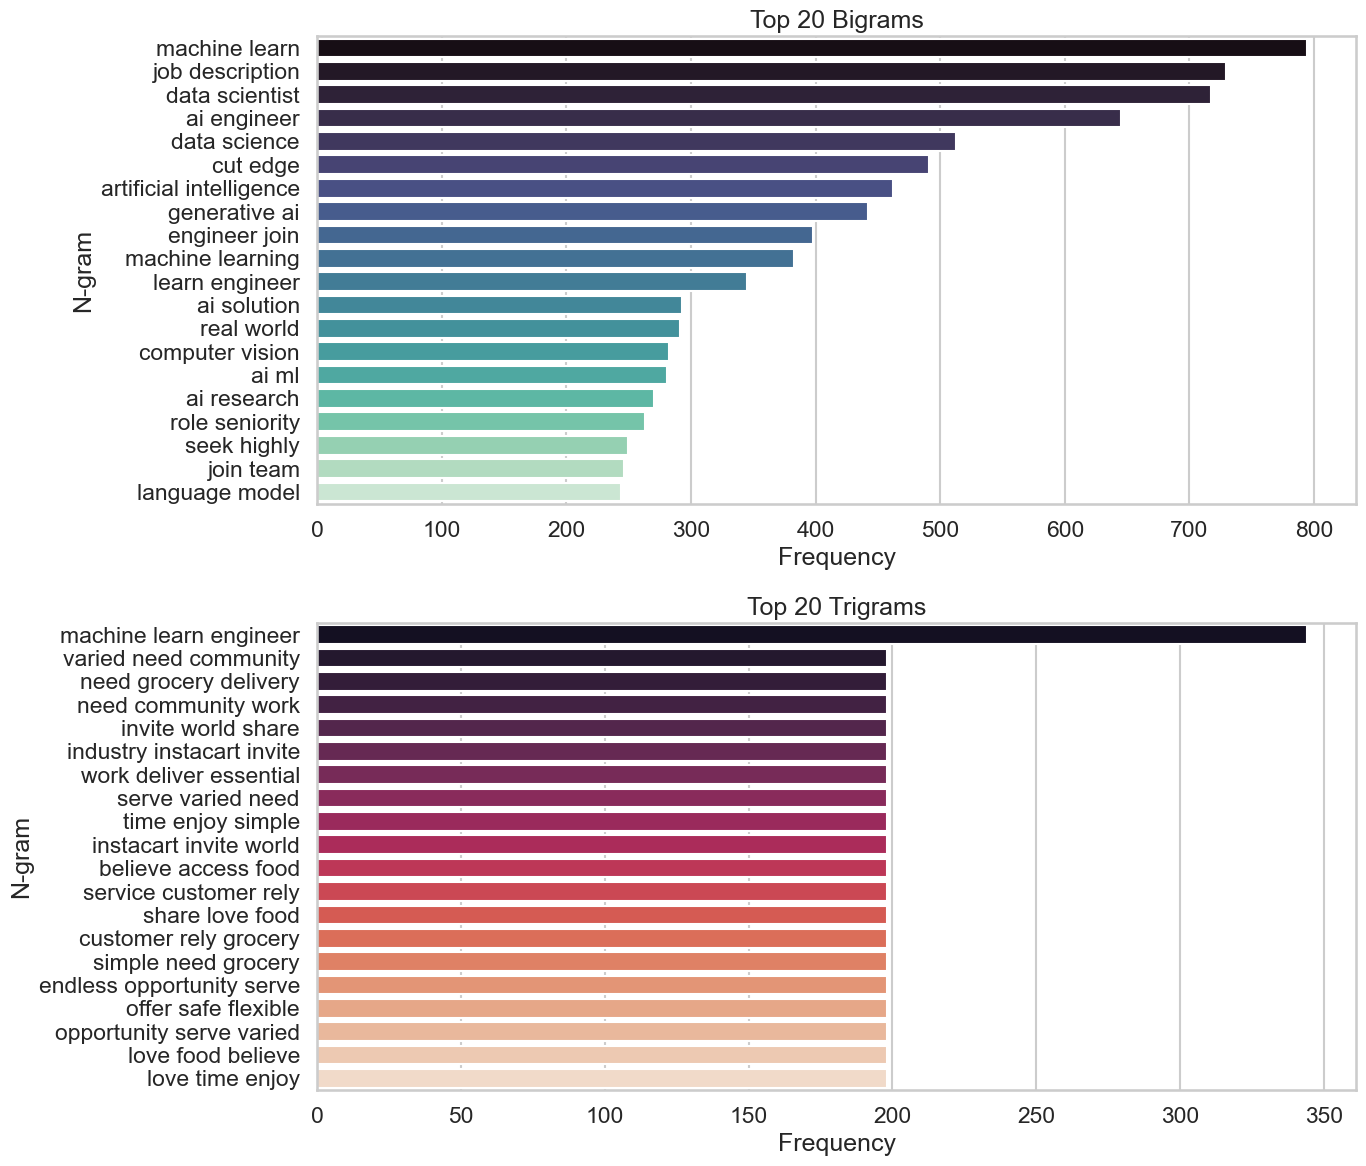

C:\Users\andyd\AppData\Local\Temp\ipykernel_19816\1753595700.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tmp, x='experience_level', y='salary_min', palette='pastel')


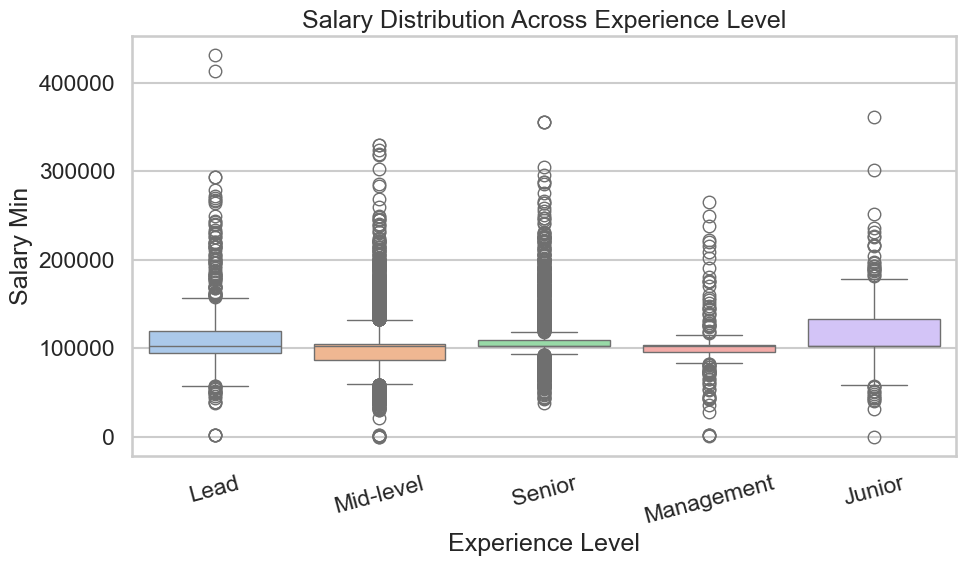

In [15]:
# 4.2 Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style='whitegrid', context='talk')

if 'clean_description' in df.columns:
    words = ' '.join(df['clean_description'].fillna('').astype(str).tolist()).split()
    frequency = Counter(words)
    top_words = dict(frequency.most_common(300))

    try:
        from wordcloud import WordCloud
        wordcloud = WordCloud(width=1400, height=700, background_color='white', colormap='viridis')
        wordcloud = wordcloud.generate_from_frequencies(top_words)
        plt.figure(figsize=(12, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title('Word Cloud of Cleaned Job Descriptions')
        plt.tight_layout()
        plt.savefig(os.path.join('output', 'wordcloud_ch4.png'), dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as exc:
        print('WordCloud unavailable:', exc)

    def top_ngrams(corpus, ngram_range=(2, 2), top_n=20):
        vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
        matrix = vectorizer.fit_transform(corpus)
        frequencies = matrix.sum(axis=0).A1
        terms = vectorizer.get_feature_names_out()
        return pd.Series(frequencies, index=terms).sort_values(ascending=False).head(top_n)

    corpus = df['clean_description'].fillna('').astype(str)
    top_bigrams = top_ngrams(corpus, (2, 2), 20)
    top_trigrams = top_ngrams(corpus, (3, 3), 20)

    fig, axes = plt.subplots(2, 1, figsize=(14, 12))
    sns.barplot(x=top_bigrams.values, y=top_bigrams.index, ax=axes[0], palette='mako')
    axes[0].set_title('Top 20 Bigrams')
    axes[0].set_xlabel('Frequency')
    axes[0].set_ylabel('N-gram')

    sns.barplot(x=top_trigrams.values, y=top_trigrams.index, ax=axes[1], palette='rocket')
    axes[1].set_title('Top 20 Trigrams')
    axes[1].set_xlabel('Frequency')
    axes[1].set_ylabel('N-gram')
    plt.tight_layout()
    plt.savefig(os.path.join('output', 'ngrams_ch4.png'), dpi=300, bbox_inches='tight')
    plt.show()

if 'salary_min' in df.columns and 'experience_level' in df.columns:
    tmp = df[['salary_min', 'experience_level']].copy()
    tmp['salary_min'] = pd.to_numeric(tmp['salary_min'], errors='coerce')
    tmp = tmp.dropna()
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=tmp, x='experience_level', y='salary_min', palette='pastel')
    plt.title('Salary Distribution Across Experience Level')
    plt.xlabel('Experience Level')
    plt.ylabel('Salary Min')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(os.path.join('output', 'salary_boxplot_ch4.png'), dpi=300, bbox_inches='tight')
    plt.show()

### 4.3 Correlation Analysis
Show correlations between the strongest TF-IDF features and salary, while checking for multicollinearity among features.

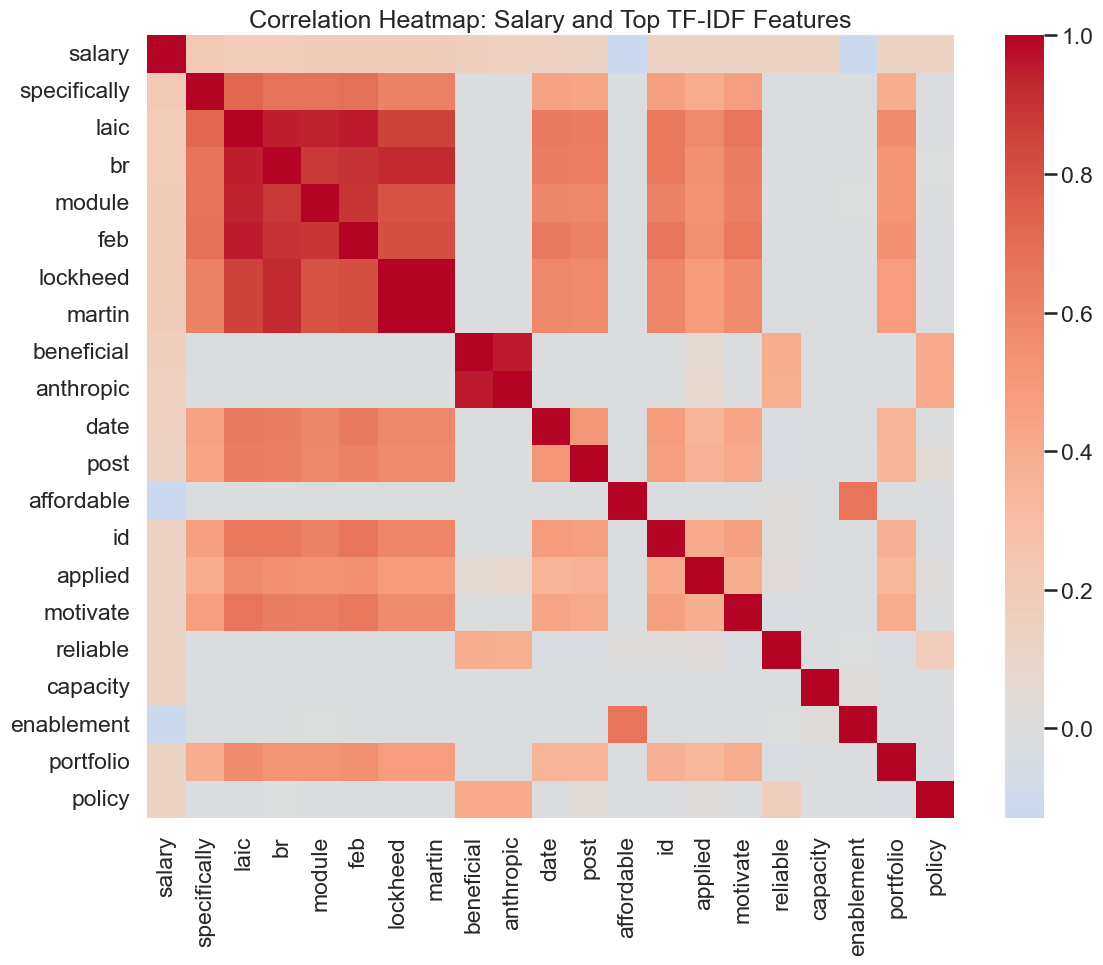

Multicollinearity note: top TF-IDF terms were selected by absolute correlation to reduce redundant features.


C:\Users\andyd\AppData\Local\Temp\ipykernel_19816\561347502.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_salary.values, y=corr_with_salary.index, palette='coolwarm')


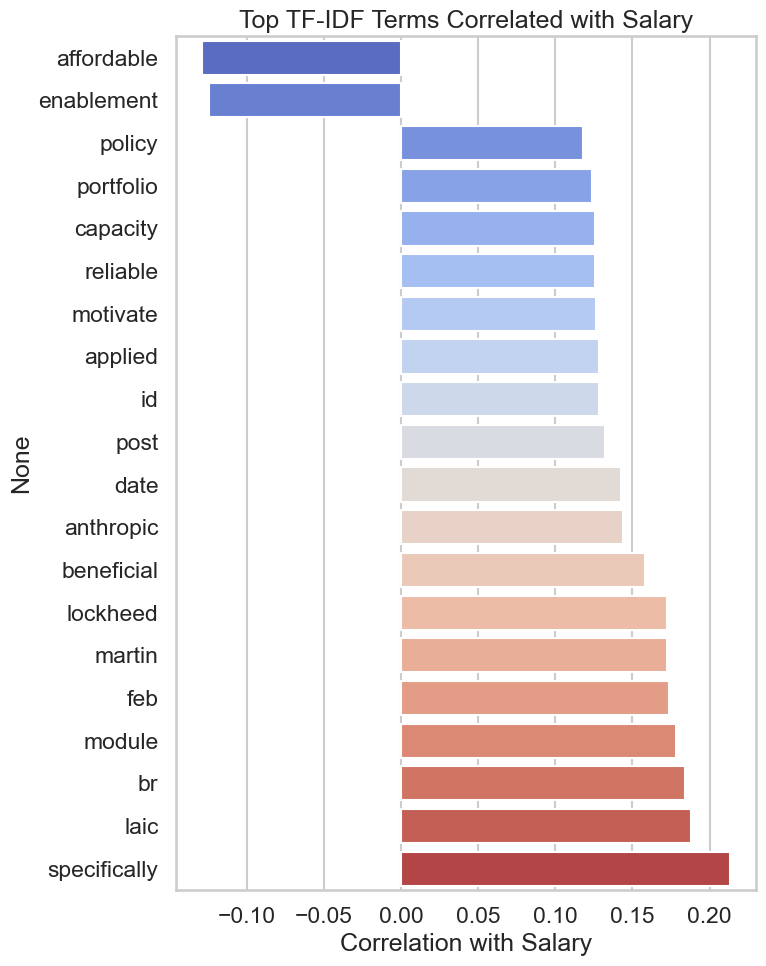

Saved: output\tfidf_salary_top_correlations.png


In [16]:
# 4.3 Correlation Analysis
from sklearn.feature_extraction.text import TfidfVectorizer

if 'clean_description' in df.columns and 'salary' in df.columns:
    text = df['clean_description'].fillna('').astype(str)
    salary_series = pd.to_numeric(df['salary'], errors='coerce')
    valid_mask = salary_series.notna()
    text = text[valid_mask]
    salary_series = salary_series[valid_mask]

    vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
    tfidf_values = vectorizer.fit_transform(text)
    tfidf_df = pd.DataFrame(tfidf_values.toarray(), columns=vectorizer.get_feature_names_out(), index=text.index)

    correlation_to_salary = tfidf_df.apply(lambda col: col.corr(salary_series)).dropna()
    top_terms = correlation_to_salary.abs().sort_values(ascending=False).head(20).index.tolist()
    heatmap_df = pd.concat([salary_series.rename('salary'), tfidf_df[top_terms]], axis=1).corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(heatmap_df, cmap='coolwarm', center=0, annot=False)
    plt.title('Correlation Heatmap: Salary and Top TF-IDF Features')
    plt.tight_layout()
    plt.savefig(os.path.join('output', 'tfidf_salary_heatmap_ch4.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print('Multicollinearity note: top TF-IDF terms were selected by absolute correlation to reduce redundant features.')

    # --- Chapter 4.3: Bar Chart of Top TF-IDF Terms Correlated with Salary (merged here) ---
    try:
        corr_with_salary = correlation_to_salary.loc[top_terms]
        corr_with_salary = corr_with_salary.sort_values()
        plt.figure(figsize=(8, 10))
        sns.barplot(x=corr_with_salary.values, y=corr_with_salary.index, palette='coolwarm')
        plt.xlabel('Correlation with Salary')
        plt.title('Top TF-IDF Terms Correlated with Salary')
        plt.tight_layout()
        out_path = os.path.join('output', 'tfidf_salary_top_correlations.png')
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        print('Saved:', out_path)
    except Exception as e:
        print('Could not create TF-IDF salary correlation bar chart:', e)
else:
    print('Required columns missing for correlation heatmap')


### 4.4 Initial Insights
The cleaned text and n-gram patterns highlight recurring AI/ML skills such as machine learning, data analysis, model deployment, MLOps, and LLM-related tooling. These signals can be used as a basis for future predictive modeling of salary outcomes and job seniority.

In [17]:
# Final verification of the cleaned output file
final_path = os.path.join('output', 'ai_jobs_global_2026_cleaned.csv')
if os.path.exists(final_path):
    final_df = pd.read_csv(final_path)
    print('Saved file:', final_path)
    print('Rows:', len(final_df))
    if 'salary_min' in final_df.columns:
        print('Missing salary_min:', final_df['salary_min'].isna().sum())
    if 'salary_max' in final_df.columns:
        print('Missing salary_max:', final_df['salary_max'].isna().sum())
else:
    print('Cleaned output file not found:', final_path)

Saved file: output\ai_jobs_global_2026_cleaned.csv
Rows: 5773
Missing salary_min: 0
Missing salary_max: 0
